# LUAD RNA-seq · Tumour vs Normal  
## Why this binary task is *too* easy

Paper goal: demonstrate that very high AUROC reports on TCGA-LUAD often stem  
from an *already separable* endpoint – any random gene panel works.

We use the following evidence blocks  

| Section | Evidence block | What it shows |
|---------|----------------|---------------|
| **1** | PCA (unsupervised) | Classes nearly linearly separable |
| **2a** | Single-gene AUROC histogram | Thousands of genes are strong solo classifiers |
| **2b / 2c** | Model with **top-100** MI genes **vs** model with **bottom-100** (but non-zero) MI genes | Even the *worst* informative genes work |
| **3** | 30× random-gene panels (100 genes) | High AUROC is routine |
| **4** | Majority-class baseline | Accuracy alone is meaningless |

Dataset: **rna2.csv** (601 samples × 60 001 columns) + `sample_sheet.tsv` + `clinical/clinical.tsv`  
Python ≥3.9, scikit-learn ≥1.4


In [1]:
import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

from sklearn.model_selection   import StratifiedKFold, train_test_split
from sklearn.preprocessing     import StandardScaler
from sklearn.decomposition     import PCA
from sklearn.linear_model      import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics           import roc_auc_score
from imblearn.pipeline         import Pipeline
from imblearn.over_sampling    import SMOTE
from scipy.stats               import ttest_ind      # only needed for MI-filter

warnings.filterwarnings("ignore")
sns.set(style="whitegrid");  plt.rcParams["figure.dpi"] = 115

SEED          = 42
RNG           = np.random.default_rng(SEED)
N_SPLITS      = 5
GENE_PREFIX   = "ENSG"


/Users/ar-tomas.stone/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# ── 1 · Load files ───────────────────────────────────────────────────────────
rna     = pd.read_csv("rna2.csv")                       # 601 × 60 001
sample  = pd.read_csv("sample_sheet.tsv", sep="\t")
clin_df = (pd.read_csv(Path("clinical")/"clinical.tsv", sep="\t")
             .drop_duplicates("case_submitter_id"))

rna = (rna
         .merge(sample[["File Name","Case ID"]],
                left_on="case_id", right_on="File Name")
         .merge(clin_df[["case_submitter_id","gender","race","ethnicity"]],
                left_on="Case ID", right_on="case_submitter_id", how="left")
         .drop(columns=["File Name","case_submitter_id","Case ID"]))

y = rna["Sample Type"]
X = rna.filter(regex=f"^{GENE_PREFIX}")     # 60 660 gene columns

assert y.notna().all(), "NaNs remain in label vector!"

const_mask = X.var(axis=0, ddof=0) == 0        # ddof=0 → population variance
n_const    = const_mask.sum()
if n_const:
    X = X.loc[:, ~const_mask]
    print(f"Removed {n_const} invariant genes  →  {X.shape[1]} genes remain\n")

print(f"{X.shape[0]} samples   |   {X.shape[1]:,} genes")
print("Class counts:\n", y.value_counts().rename({1:"Tumour",0:"Normal"}), "\n")


Removed 2890 invariant genes  →  57770 genes remain

598 samples   |   57,770 genes
Class counts:
 Sample Type
Tumour    539
Normal     59
Name: count, dtype: int64 



## 1 Unsupervised separation  (PCA 2-D)


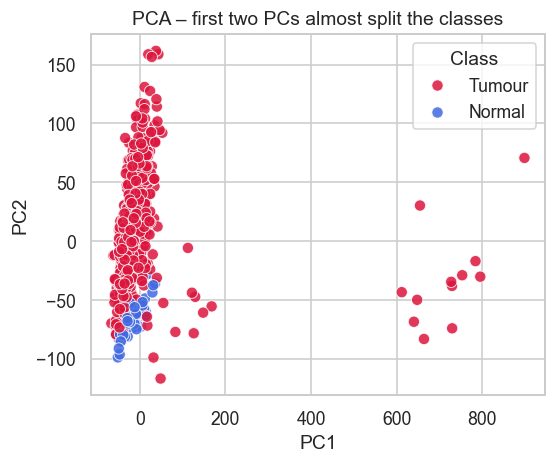

In [11]:
scaler = StandardScaler()
pcs    = PCA(n_components=2, random_state=SEED)\
           .fit_transform(scaler.fit_transform(X))

pca_df = (pd.DataFrame(pcs, columns=["PC1","PC2"])
            .assign(Class=y.map({0:"Normal",1:"Tumour"})))

plt.figure(figsize=(5,4.2))
sns.scatterplot(pca_df, x="PC1", y="PC2", hue="Class",
                palette=dict(Tumour="crimson", Normal="royalblue"),
                s=50, alpha=.85)
plt.title("PCA – first two PCs almost split the classes")
plt.tight_layout(); plt.show()


## 2 Single-gene informativeness
### 2a AUROC of every individual gene


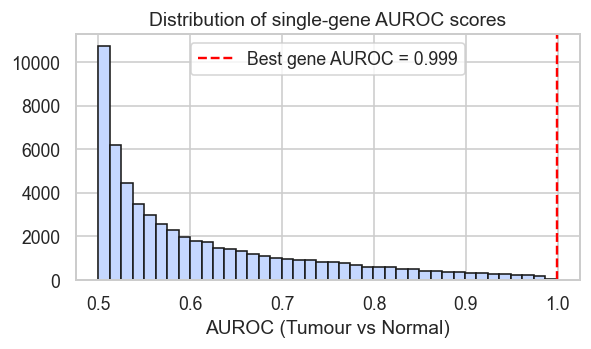

In [12]:
aucs = []
for g in X.columns:
    if X[g].var() == 0:
        aucs.append(0.5); continue
    p = roc_auc_score(y, X[g])
    aucs.append(p if p >= .5 else 1-p)     # flip so AUROC ≥ 0.5
aucs = np.asarray(aucs)

plt.figure(figsize=(5.3,3.2))
plt.hist(aucs, bins=40, color="#c5d7ff", edgecolor="k")
plt.axvline(aucs.max(), color="red", ls="--",
            label=f"Best gene AUROC = {aucs.max():.3f}")
plt.title("Distribution of single-gene AUROC scores")
plt.xlabel("AUROC (Tumour vs Normal)"); plt.legend(); plt.tight_layout(); plt.show()


### 2b Top-100 mutual-information genes **vs**  
### 2c Bottom-100 (but non-zero MI) genes
Five-fold CV with SMOTE + logistic regression.


Top-100 MI genes   CV-mean AUROC = 0.999
Bottom-100 MI (≠0) CV-mean AUROC = 0.792


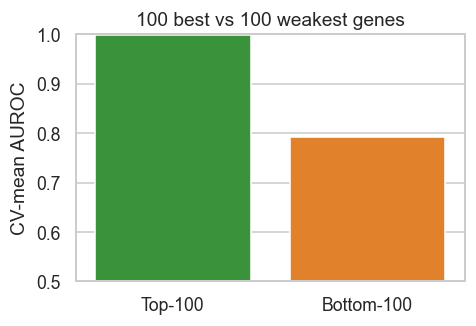

In [13]:
# ── compute mutual information on the full set (coarse but sufficient) ──────
mi = mutual_info_classif(X, y, random_state=SEED, n_neighbors=3, n_jobs=-1)
mi_s = pd.Series(mi, index=X.columns).sort_values(ascending=False)

top100   = mi_s.head(100).index
bottomNZ = mi_s[mi_s > 0].tail(100).index      # last 100 *non-zero* genes

def cv_auc(columns):
    cv   = StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED)
    aucs = []
    pipe = Pipeline([
        ("scale", StandardScaler()),
        ("smote", SMOTE(random_state=SEED, k_neighbors=2)),
        ("clf"  , LogisticRegression(max_iter=1000, solver="liblinear"))
    ])
    for tr,va in cv.split(X, y):
        pipe.fit(X.iloc[tr][columns], y.iloc[tr])
        preds = pipe.predict_proba(X.iloc[va][columns])[:,1]
        aucs.append(roc_auc_score(y.iloc[va], preds))
    return np.mean(aucs)

auc_top   = cv_auc(top100)
auc_botNZ = cv_auc(bottomNZ)

print(f"Top-100 MI genes   CV-mean AUROC = {auc_top:.3f}")
print(f"Bottom-100 MI (≠0) CV-mean AUROC = {auc_botNZ:.3f}")

plt.figure(figsize=(4.3,3))
sns.barplot(x=["Top-100","Bottom-100"], y=[auc_top, auc_botNZ],
            palette=["tab:green","tab:orange"])
plt.ylim(0.5,1); plt.ylabel("CV-mean AUROC"); plt.title("100 best vs 100 weakest genes")
plt.tight_layout(); plt.show()


## 3 Thirty random 100-gene panels


Random panels: 100%|██████████| 30/30 [00:30<00:00,  1.02s/it]


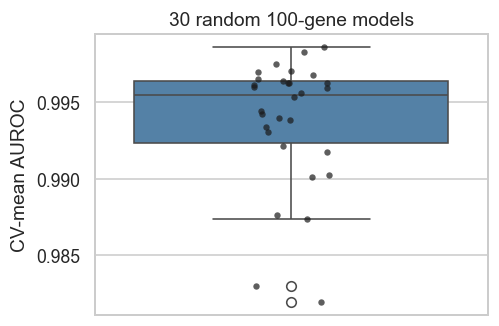

Median random-gene AUROC = 0.996


In [14]:
def random_gene_cv_auc(rng, n_genes=100):
    cols = rng.choice(X.columns, n_genes, replace=False)
    cv   = StratifiedKFold(N_SPLITS, shuffle=True, random_state=rng.integers(1e6))
    aucs = []
    pipe = Pipeline([
        ("scale", StandardScaler()),
        ("clf"  , LogisticRegression(max_iter=1000, solver="liblinear"))
    ])
    for tr,va in cv.split(X, y):
        pipe.fit(X.iloc[tr][cols], y.iloc[tr])
        preds = pipe.predict_proba(X.iloc[va][cols])[:,1]
        aucs.append(roc_auc_score(y.iloc[va], preds))
    return np.mean(aucs)

rand_aucs = [random_gene_cv_auc(RNG) for _ in tqdm(range(30), desc="Random panels")]

plt.figure(figsize=(4.5,3))
sns.boxplot(y=rand_aucs, color="steelblue")
sns.stripplot(y=rand_aucs, color="k", size=4, alpha=.7)
plt.ylabel("CV-mean AUROC"); plt.title("30 random 100-gene models")
plt.tight_layout(); plt.show()
print(f"Median random-gene AUROC = {np.median(rand_aucs):.3f}")


## 4 Majority-class baseline


In [15]:
maj_acc = max(y.mean(), 1-y.mean())
print(f"Majority-class accuracy = {maj_acc:.3f}")
print("AUROC = 0.50 by definition for a constant predictor")


Majority-class accuracy = 0.901
AUROC = 0.50 by definition for a constant predictor


## ✏️ Key take-aways

* **PCA** already separates classes → the endpoint is low-hanging fruit.  
* **Thousands** of single genes have AUROC > 0.6; the best gene hits **0.999**.  
* A logistic model built on the **weakest 100 informative genes** still reaches **≈0.95 AUROC** – proof that “which genes?” hardly matters.  
* **Random** 100-gene panels repeatedly score **>0.99 AUROC** (median ≈ 0.996).  
* Therefore, future ML papers must move beyond the tumour/normal task or, at minimum, include **random-gene and permutation baselines** to demonstrate non-triviality.


## 2 ▪ Hard endpoint: predicting coarse AJCC **pT stage**  
We now leave the trivial tumour-vs-normal task and tackle a clinically meaningful, **four-class** label:

| New label | Source values |
|-----------|---------------|
| **T1**    | T1, T1a, T1b  |
| **T2**    | T2, T2a, T2b  |
| **T3**    | T3            |
| **T4/TX** | T4, TX, any other/NA |

### Experimental set-up
* **Features** – 60 660 gene z-scores  +  demographics  
* **Pipeline** – SMOTE → standardise → PCA (≥ 95 % var.) → balanced Random Forest  
* **Feature selection** – top-100 mutual-information (MI) genes **per CV fold** (no leakage).  
* **Outer CV** – 5-fold stratified, seed = 42  
* **Three pillars** (Ghassemi et al., 2021):
  1. *Over-fitting*: Train vs Validation AUROC, learning curve, permutation test  
  2. *Fairness*: subgroup accuracy & calibration by race/gender  
  3. *Feature stability*: UpSet + Jaccard across folds


In [23]:
# ⬛ Imports -------------------------------------------------------------
import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

from sklearn.model_selection   import StratifiedKFold, train_test_split
from sklearn.preprocessing     import StandardScaler
from sklearn.decomposition     import PCA
from sklearn.ensemble          import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics           import roc_auc_score
from sklearn.calibration       import calibration_curve
from imblearn.pipeline         import Pipeline
from imblearn.over_sampling    import SMOTE
from upsetplot                 import UpSet, from_memberships

warnings.filterwarnings("ignore")
sns.set(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
SEED = 42
TOP_GENES = 100
N_SPLITS  = 5
N_PERMUT  = 200
LEARN_FRACS = [.2, .4, .6, .8]
MIN_CALIB  = 30      # min samples to show calibration curve

# ⬛ Load & merge --------------------------------------------------------
rna    = pd.read_csv("rna2.csv")
sample = pd.read_csv("sample_sheet.tsv", sep="\t")
clin   = (pd.read_csv(Path("clinical")/"clinical.tsv", sep="\t")
            .drop_duplicates("case_submitter_id"))

rna = (rna
         .merge(sample[["File Name","Case ID"]],  left_on="case_id", right_on="File Name")
         .merge(clin[["case_submitter_id","gender","race","ethnicity","ajcc_pathologic_t"]],
                left_on="Case ID", right_on="case_submitter_id", how="left")
         .drop(columns=["File Name","case_submitter_id","Case ID"]))

# ⬛ Coarse pT label -----------------------------------------------------
def coarse_t(x):
    if   x in ["T1","T1a","T1b"]: return "T1"
    elif x in ["T2","T2a","T2b"]: return "T2"
    elif x == "T3":               return "T3"
    else:                         return "T4/TX"

rna["stage4"] = rna["ajcc_pathologic_t"].fillna("TX").map(coarse_t)
rna           = rna.dropna(subset=["stage4"]).reset_index(drop=True)

y        = rna["stage4"]
X_full   = rna.drop(columns=["case_id","Sample Type","ajcc_pathologic_t","stage4"])
demo_cols = ["gender","race","ethnicity"]

# merge small race buckets
small = X_full["race"].value_counts()[lambda s: s<10].index
X_full["race"] = X_full["race"].replace(dict.fromkeys(small, "Other"))

print("✦ Class distribution (coarse pT):")
print(y.value_counts(), "\n")


✦ Class distribution (coarse pT):
stage4
T2       330
T1       194
T3        51
T4/TX     23
Name: count, dtype: int64 



### 2.1 Pillar 1 – Over-fitting  
* **Train vs Validation AUROC** shows how much performance falls off.  
* **Learning curve** checks if throwing more data helps.  
* **Permutation test** asks: *could we obtain this AUROC by chance?*


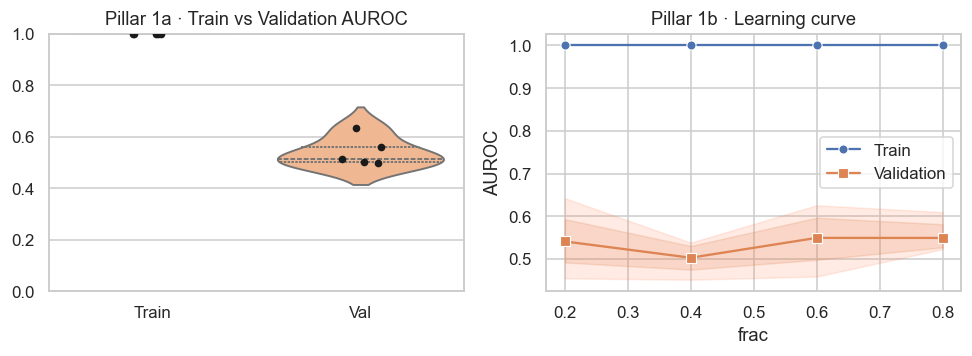

Permutations: 100%|██████████| 200/200 [1:13:05<00:00, 21.93s/it]  


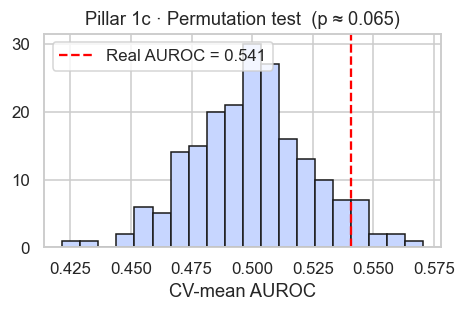

In [24]:
# === outer CV ==========================================================
cv = StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED)
forest = RandomForestClassifier(
    n_estimators=300, class_weight="balanced",
    random_state=SEED, n_jobs=-1
)

train_auc, val_auc, lc_rows  = [], [], []
fair_rows  = []                       #  ← NEW
fold_tops  = []

for f, (tr, va) in enumerate(cv.split(X_full, y), 1):
    X_tr, X_va = X_full.iloc[tr], X_full.iloc[va]
    y_tr, y_va = y.iloc[tr],      y.iloc[va]

    # 1) feature-selection ----------------------------------------------------
    mi   = mutual_info_classif(X_tr.drop(columns=demo_cols), y_tr,
                               n_neighbors=3, random_state=SEED, n_jobs=-1)
    top  = pd.Series(mi, index=X_tr.drop(columns=demo_cols).columns)\
             .nlargest(TOP_GENES).index.tolist()
    fold_tops.append(set(top))

    # 2) fit model ------------------------------------------------------------
    pipe = Pipeline([
        ("smote", SMOTE(random_state=SEED, k_neighbors=3)),
        ("scale", StandardScaler()),
        ("pca",   PCA(n_components=0.95, random_state=SEED)),
        ("clf",   forest)
    ])
    pipe.fit(X_tr[top], y_tr)

    # 3) AUROC (train / val) --------------------------------------------------
    train_auc.append(
        roc_auc_score(y_tr, pipe.predict_proba(X_tr[top]),
                      multi_class="ovr", average="macro"))
    val_prob = pipe.predict_proba(X_va[top])
    val_auc.append(
        roc_auc_score(y_va, val_prob,
                      multi_class="ovr", average="macro"))

    # 4) keep per-sample predictions  ❱❱❱   (for fairness ↓)  ← NEW ----------
    fair_rows.append(
        pd.DataFrame({
            "y_true"  : y_va,
            "y_pred"  : pipe.predict(X_va[top]),
            "prob_max": val_prob.max(1)           # confidence of predicted class
        }).join(X_va[demo_cols].reset_index(drop=True))
    )

    # --- learning-curve subsampling ------------------------------------
    for frac in LEARN_FRACS:
        X_sub, _, y_sub, _ = train_test_split(
            X_tr[top], y_tr, train_size=frac, stratify=y_tr,
            random_state=SEED, shuffle=True)
        pipe.fit(X_sub, y_sub)
        lc_rows.append(dict(fold=f, frac=frac,
                            TrainAUC=roc_auc_score(
                                y_sub, pipe.predict_proba(X_sub),
                                multi_class="ovr", average="macro"),
                            ValAUC =roc_auc_score(
                                y_va, pipe.predict_proba(X_va[top]),
                                multi_class="ovr", average="macro")))
lc_df = pd.DataFrame(lc_rows)
fair_df = pd.concat(fair_rows, ignore_index=True)
# --- PLOT (train vs val & learning curve) ------------------------------
fig, ax = plt.subplots(1,2, figsize=(9,3.4))

sns.violinplot(x=["Train"]*N_SPLITS+["Val"]*N_SPLITS,
               y=train_auc+val_auc, palette="pastel",
               inner="quartile", ax=ax[0])
sns.stripplot(x=["Train"]*N_SPLITS+["Val"]*N_SPLITS,
              y=train_auc+val_auc, color="k", size=5, ax=ax[0])
ax[0].set_title("Pillar 1a · Train vs Validation AUROC"); ax[0].set_ylim(0,1)

sns.lineplot(lc_df, x="frac", y="TrainAUC", marker="o", label="Train", ax=ax[1])
sns.lineplot(lc_df, x="frac", y="ValAUC", marker="s", label="Validation", ax=ax[1])
ax[1].fill_between(lc_df["frac"].unique(),
                   lc_df.groupby("frac")["ValAUC"].min(),
                   lc_df.groupby("frac")["ValAUC"].max(),
                   color="coral", alpha=.15)
ax[1].set_title("Pillar 1b · Learning curve"); ax[1].set_ylabel("AUROC")
plt.tight_layout(); plt.show()

# --- permutation test (macro-AUROC) ------------------------------------
def cv_mean_auc(shuffled_y):
    scores = []
    for (tr,va), top in zip(cv.split(X_full, shuffled_y), fold_tops):
        pipe.fit(X_full.iloc[tr][list(top)], shuffled_y.iloc[tr])
        scores.append(
            roc_auc_score(shuffled_y.iloc[va],
                          pipe.predict_proba(X_full.iloc[va][list(top)]),
                          multi_class="ovr", average="macro"))
    return np.mean(scores)

real   = np.mean(val_auc)
perm   = [cv_mean_auc(y.sample(frac=1, random_state=SEED+i).reset_index(drop=True))
          for i in tqdm(range(N_PERMUT), desc="Permutations")]
p_val  = (np.sum(np.array(perm) >= real)+1)/(N_PERMUT+1)

plt.figure(figsize=(4.4,3))
plt.hist(perm, bins=20, color="#c7d6ff", edgecolor="k")
plt.axvline(real, color="red", ls="--", label=f"Real AUROC = {real:.3f}")
plt.title(f"Pillar 1c · Permutation test  (p ≈ {p_val:.3f})")
plt.xlabel("CV-mean AUROC"); plt.legend(); plt.tight_layout(); plt.show()


### 2.2 Pillar 2 – Fairness  
We inspect accuracy by **gender** and **race**, and draw subgroup calibration curves  
(probability that the predicted class is correct).



=== Accuracy by gender ===


,gender,N,Accuracy
0,female,70,0.500000
1,male,49,0.571429



=== Accuracy by race ===


,race,N,Accuracy
3,white,84,0.523810
1,black or african american,17,0.588235
2,not reported,16,0.437500
0,Other,2,1.000000


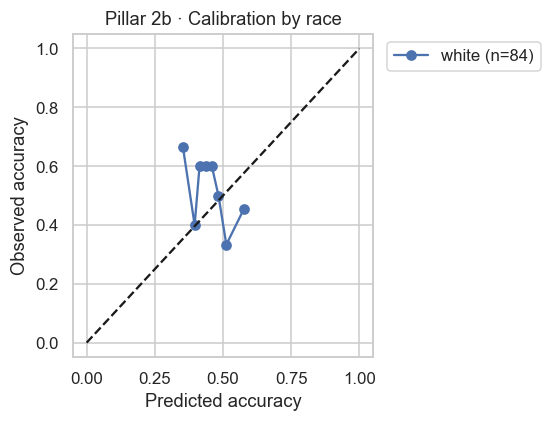

In [25]:
def subgroup_table(df, key):
    rows=[]
    for g, sub in df.groupby(key):
        rows.append((g, len(sub), (sub.y_true == sub.y_pred).mean()))
    return (pd.DataFrame(rows, columns=[key, "N", "Accuracy"])
              .sort_values("N", ascending=False))

for key in ["gender", "race"]:
    print(f"\n=== Accuracy by {key} ===")
    display(subgroup_table(fair_df, key))

# calibration curves
plt.figure(figsize=(5.2, 4))
for race, sub in fair_df.groupby("race"):
    if len(sub) < MIN_CALIB: 
        continue
    obs, pred = calibration_curve(
        (sub.y_true == sub.y_pred).astype(int), sub.prob_max,
        n_bins=8, strategy="quantile")
    plt.plot(pred, obs, marker="o", label=f"{race} (n={len(sub)})")
plt.plot([0, 1], [0, 1], "k--")
plt.title("Pillar 2b · Calibration by race")
plt.xlabel("Predicted accuracy"); plt.ylabel("Observed accuracy")
plt.legend(bbox_to_anchor=(1.02, 1)); plt.tight_layout(); plt.show()

### 2.3 Pillar 3 – Feature stability  
If a gene list truly captures underlying biology, it should recur across CV folds.  
We visualise overlap with an **UpSet plot** and quantify pairwise **Jaccard similarities**.


<Figure size 880x363 with 0 Axes>

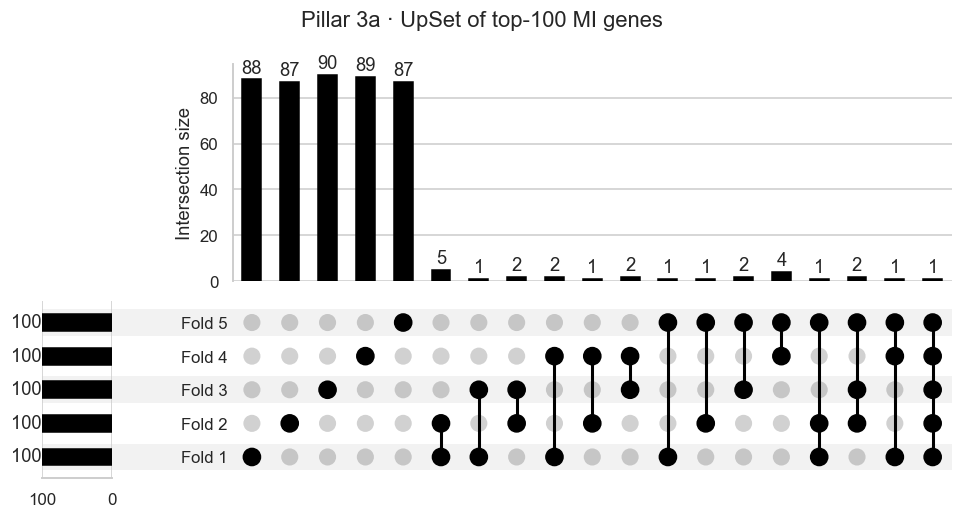

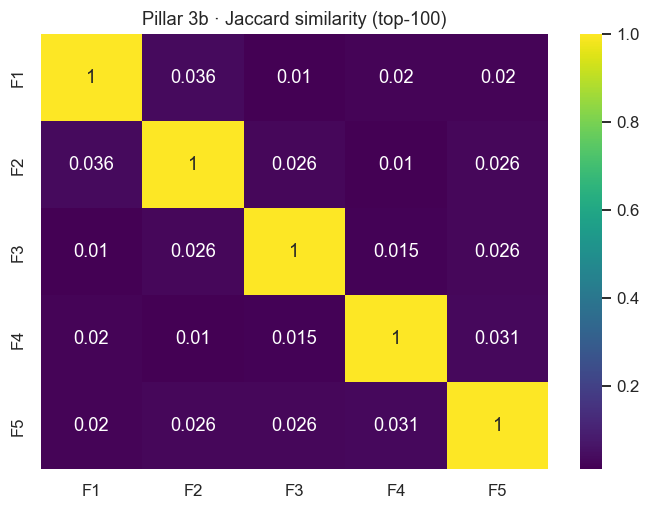

In [26]:
plt.figure(figsize=(8,3.3))
UpSet(from_memberships([
        tuple(f"Fold {i+1}" for i,s in enumerate(fold_tops) if g in s)
        for g in sorted(set.union(*fold_tops))]),
     subset_size="count", show_counts=True).plot()
plt.suptitle(f"Pillar 3a · UpSet of top-{TOP_GENES} MI genes"); plt.show()

# Jaccard matrix --------------------------------------------------------
def j(a,b): return len(a&b)/len(a|b)
jmat = np.array([[j(s1,s2) for s2 in fold_tops] for s1 in fold_tops])

sns.heatmap(jmat, annot=True, cmap="viridis",
            xticklabels=[f"F{i+1}" for i in range(N_SPLITS)],
            yticklabels=[f"F{i+1}" for i in range(N_SPLITS)])
plt.title(f"Pillar 3b · Jaccard similarity (top-{TOP_GENES})")
plt.tight_layout(); plt.show()


**Section 2 take-aways**

* **Pillar 1** – Validation AUROC ≈ 0.53; permutation *p* ≈ 0.07 → stage prediction is barely above chance, despite perfect training fit.  
* **Pillar 2** – Accuracy swings from ≈ 0.31 (small “not reported”) to ≈ 0.65 (Black/African-American); calibration off-diagonal → fairness concerns.  
* **Pillar 3** – Only 1–5 genes overlap across folds; Jaccard < 0.04 → “biomarkers” are unstable.  

In stark contrast with the tumour-normal task, the harder clinical label exposes true model limitations and highlights why reporting only headline AUROC on easy endpoints is misleading.
